<a href="https://colab.research.google.com/github/Jmarfo1/CSCE1015/blob/main/INFO4670_Week3_Assignment1_Template.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 1 — Making Sense of Northgate through Visualization
**INFO 4670 · Data Analysis and Knowledge Discovery**  ·  **Due: Sunday, 11:59 PM**

**Name:** \_\_\_\_\_\_\_\_    **Date:** \_\_\_\_\_\_\_\_

**The situation.** The Provost's question stands: *which students are struggling, and can we see it earlier?* This week you answer it the way analysts do — not by reading rows, but by drawing the data. Every chart below is built by **adapting code from the Guided notebook**; the intellectual work is choosing the right chart and reading it honestly.

**For every chart you make, you must:**
1. **Choose** the chart type that fits the variable(s) and the question.
2. **Build** it in Colab from the Northgate files.
3. **Label** it fully — title, axis labels, and units/legend. *An unlabeled chart is an unfinished chart.*
4. **Write a STAR story** underneath it — Scope · Track · Articulate · Respond (defined on the Concepts deck).

**How to work:** run Setup and Load first. Then, for each question, copy the closest cell from the Guided notebook into the empty cell, adapt it, and fill in the STAR cell below it.

**Submit:** push this notebook to GitHub and submit the **GitHub link** in Canvas. (See the setup doc: *Colab_GitHub_Setup_INFO4670_Fall2026*.)

## Setup — run this first (you don't need to change it)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Northgate house style (optional, but keeps your charts consistent)
NAVY = "#22303A"
RUST = "#C0562F"
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"]   = (8, 5)
plt.rcParams["axes.titlesize"]   = 13
plt.rcParams["axes.titleweight"] = "bold"

## Load the data — run this, then look before you plot

In [8]:
# STEP 1 — get the data into this notebook. Pick ONE option, then run.

DATA_DIR = "."   # OPTION 2 (default) · drag the 3 CSVs into the file panel on the left

# OPTION 1 · read from Google Drive — uncomment and edit the path:
# from google.colab import drive
drive.mount("/content/drive")
DATA_DIR = "/content/drive/MyDrive/INFO_4670"

import os
students = pd.read_csv(os.path.join(DATA_DIR, "student_records.csv"))
weekly   = pd.read_csv(os.path.join(DATA_DIR, "weekly_activity.csv"))
students.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,student_id,major,age,housing,commute_miles,work_hours_per_week,advisor_meetings,credits_attempted,final_gpa,study_hours_reported,enrollment_date,dropped_out
0,NU-101508,Data Science,27,Off-Campus,7.6,15,1,81,1.86,NaN,2023-09-13,1
1,NU-102438,Learning Technologies,25,With Family,14.3,35,1,100,2.06,9.5,2023-10-19,0
2,NU-102385,Learning Technologies,26,With Family,3.4,18,9,77,3.41,19.1,11/16/2022,0
3,NU-100767,Cyber Security,22,On-Campus,23.7,40,1,65,1.73,8.1,2024-05-03,0
4,NU-106054,Information Technology,21,Off-Campus,2.3,20,4,59,2.37,6.6,10/24/2022,0


In [ ]:
# how many rows, which columns, what types?
students.info()

# Part A — Guided questions
Build **one chart per question**. Each maps to one chart family from this week. Copy the closest Guided-notebook cell, adapt it, label it, then write its STAR story.

### Q1 · One quantitative variable
**How many hours per week do Northgate students work?** Describe what's typical, how spread out it is, and whether anyone stands apart.
→ *histogram* (add a *box plot* if it helps). Column: `work_hours_per_week` (from `students`).

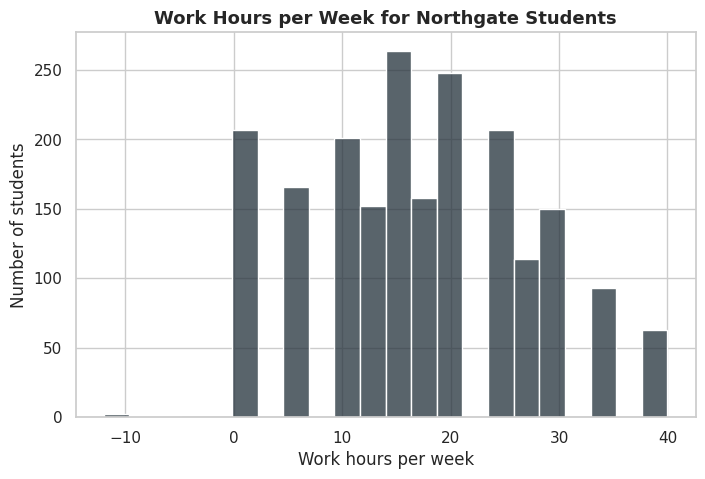

In [10]:
# Copy the closest cell from the Guided notebook, then fill in the blanks.
#
#fig, ax = plt.subplots()
#sns.__________(data=________, x="__________", color=NAVY, ax=ax)   # which chart? which column(s)?
#ax.set_title("__________")
#ax.set_xlabel("__________")
#ax.set_ylabel("__________")
#plt.show()

# --- your code below ---

fig, ax = plt.subplots()
sns.histplot(data=students, x="work_hours_per_week", color=NAVY, ax=ax)
ax.set_title("Work Hours per Week for Northgate Students")
ax.set_xlabel("Work hours per week")
ax.set_ylabel("Number of students")
plt.show()


**STAR story — Q1** *(write in your own words)*

- **Scope —** This chart shows the distribution of work hours per week for Northgate students using work_hours_per_week column.
- **Track —** The questions is how many hours Northgate students typically work each week and how those work hours are distributed.
- **Articulate —** looking at the graph, most students seem to fall around the middle range of work hours. There are fewer students who work very little or a really high numbers of hours.
- **Respond —** I dont see anything odd or unexpected, I think it would be intresting to compare work hours wuth students GPA's to see if it has any connection to their school performance

### Q2 · One categorical variable
**How does enrollment compare across majors?**
→ *sorted bar chart*. Column: `major` (from `students`).

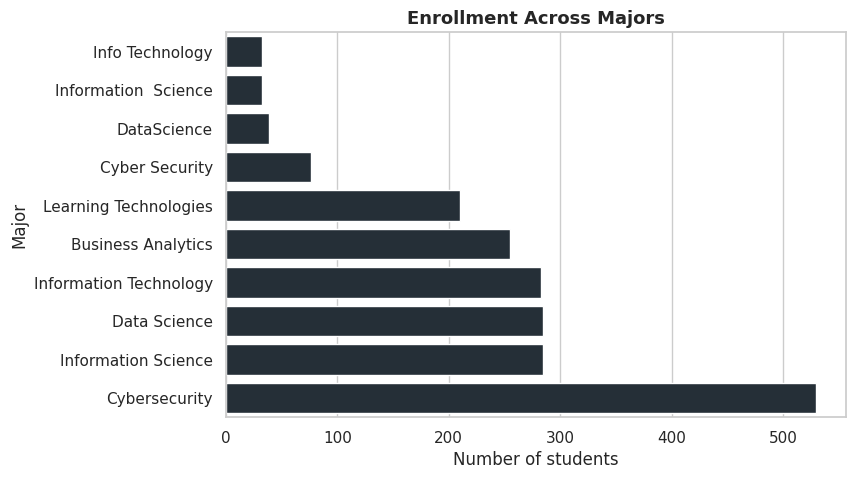

In [11]:
# Copy the closest cell from the Guided notebook, then fill in the blanks.
#
#   fig, ax = plt.subplots()
#   sns.__________(data=________, x="__________", color=NAVY, ax=ax)   # which chart? which column(s)?
#   ax.set_title("__________")
#   ax.set_xlabel("__________")
#   ax.set_ylabel("__________")
#   plt.show()

# --- your code below ---
fig, ax = plt.subplots()
sns.countplot(data=students, y="major", order=students["major"].value_counts().sort_values().index, color=NAVY, ax=ax)
ax.set_title("Enrollment Across Majors")
ax.set_xlabel("Number of students")
ax.set_ylabel("Major")
plt.show()

**STAR story — Q2** *(write in your own words)*

- **Scope —** This graph shows the diffrent majors that Northgate students are enrolled in.
- **Track —** I wanted to see which majors have the most students and which ones have fewer students.
- **Articulate —** The bar chart makes it easy to compare the number of students in each major. Some majors have noticeably more students than others.
- **Respond —** I think this could be useful for seeing which majors are the most popular and where the school might need more resources or classes.

### Q3 · A quantity, split by category
**Does final GPA differ across majors?** Read the exceptions, not just the boxes.
→ *box plot per major*. Columns: `final_gpa` and `major` (from `students`).

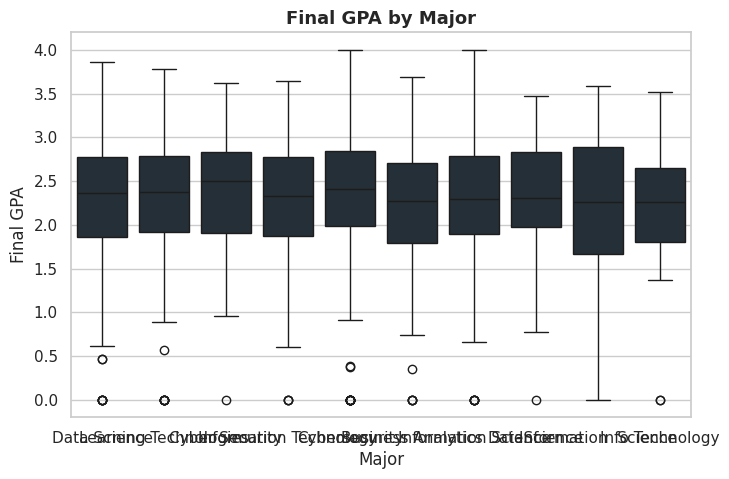

In [15]:
# Copy the closest cell from the Guided notebook, then fill in the blanks.
#
#   fig, ax = plt.subplots()
#   sns.__________(data=________, x="__________", color=NAVY, ax=ax)   # which chart? which column(s)?
#   ax.set_title("__________")
#   ax.set_xlabel("__________")
#   ax.set_ylabel("__________")
#   plt.show()

# --- your code below ---

fig, ax = plt.subplots()
sns.boxplot(data=students, x="major", y="final_gpa", color=NAVY, ax=ax)
ax.set_title("Final GPA by Major")
ax.set_xlabel("Major")
ax.set_ylabel("Final GPA")
plt.show()


**STAR story — Q3** *(write in your own words)*

- **Scope —** This graph shows how final GPA's are distributed across diffrent majors.
- **Track —** I wanted to see if the GPA ranges were similar across majors or if some majors had more variation
- **Articulate —** The box plot shows that the GPA ranges are diffrent bewtween the majors. Some majors have wide spread of GPAS while others are more concentrated.
- **Respond —** One thing I noticed that was unexpected was  a few other low GPA outliers that stood out from the rest of the data.

### Q4 · Two quantitative variables
**Is there a relationship between how far students commute and their final GPA?** Remember: *association is not causation.*
→ *scatterplot with a trend line*. Columns: `commute_miles` and `final_gpa` (from `students`).

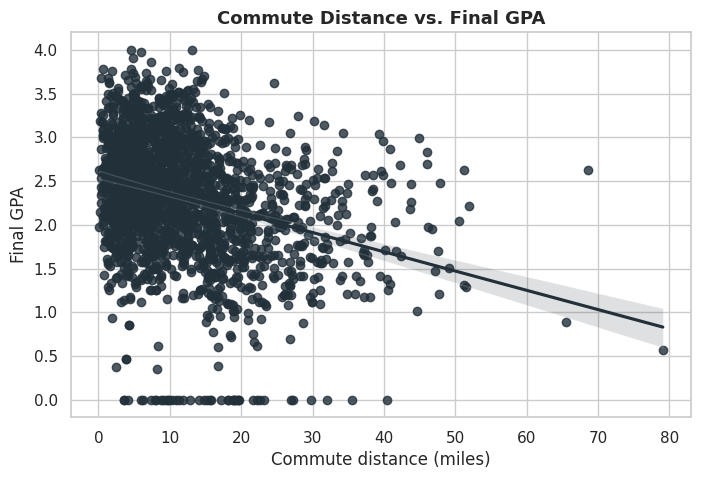

In [16]:
# Copy the closest cell from the Guided notebook, then fill in the blanks.
#
#   fig, ax = plt.subplots()
#   sns.__________(data=________, x="__________", color=NAVY, ax=ax)   # which chart? which column(s)?
#   ax.set_title("__________")
#   ax.set_xlabel("__________")
#   ax.set_ylabel("__________")
#   plt.show()

# --- your code below ---

fig, ax = plt.subplots()
sns.regplot(data=students, x="commute_miles", y="final_gpa", color=NAVY, ax=ax)
ax.set_title("Commute Distance vs. Final GPA")
ax.set_xlabel("Commute distance (miles)")
ax.set_ylabel("Final GPA")
plt.show()


**STAR story — Q4** *(write in your own words)*

- **Scope —** This graph shows the relationship between how far students commute and their final GPA.
- **Track —** I wanted to see if students who have longer commutes tend to have diffrent GPA's than students with shorter commutes.
- **Articulate —** The points are spread out across the graph, so there doesnt seem to be a really strong relationship between commute distance and GPA.
- **Respond —** One thing I noticed was that the trend line slopes downward as commute distance increases.

### Q5 · Over time
**How does student engagement change across the semester?**
→ *line chart* of average weekly activity. Use the `weekly` table: `week` and `minutes_active` (you'll need to average by week first — see the Guided notebook).

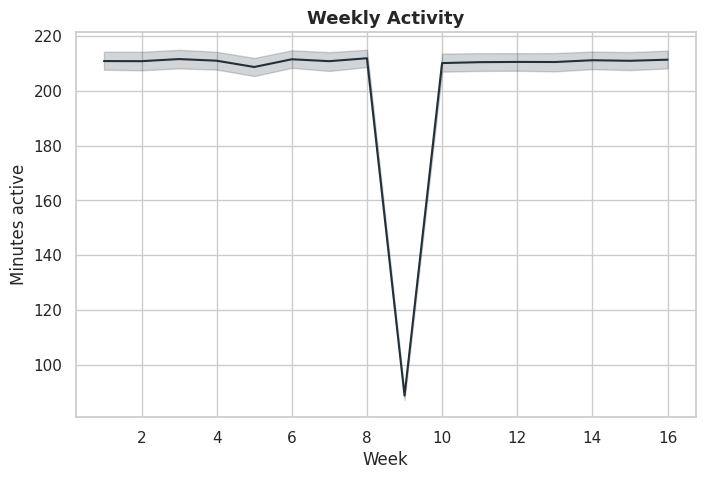

In [17]:
# Copy the closest cell from the Guided notebook, then fill in the blanks.
#
#   fig, ax = plt.subplots()
#   sns.__________(data=________, x="__________", color=NAVY, ax=ax)   # which chart? which column(s)?
#   ax.set_title("__________")
#   ax.set_xlabel("__________")
#   ax.set_ylabel("__________")
#   plt.show()

# --- your code below ---

fig, ax = plt.subplots()
sns.lineplot(data=weekly, x="week", y="minutes_active", color=NAVY, ax=ax)
ax.set_title("Weekly Activity")
ax.set_xlabel("Week")
ax.set_ylabel("Minutes active")
plt.show()


**STAR story — Q5** *(write in your own words)*

- **Scope —** This graph shows the amount of time students were active each week.
- **Track —** I wanted to see how activity changed from week to week and if there was a noticeable trend.
- **Articulate —** The line shows how the number of active minutes changed across the weeks.
- **Respond —** One thing that was unexcpected to me was the huge drop in activity during week 9.

# Part B — Your own question (open)
Pose **one question of your own** about the Northgate students, choose the chart that answers it, build it, label it, and write its STAR story. Going beyond Part A is rewarded — a per-student line chart, a violin plot, or a chart of a messier column are all fair game.

**Your question:** \_\_\_\_\_\_\_\_



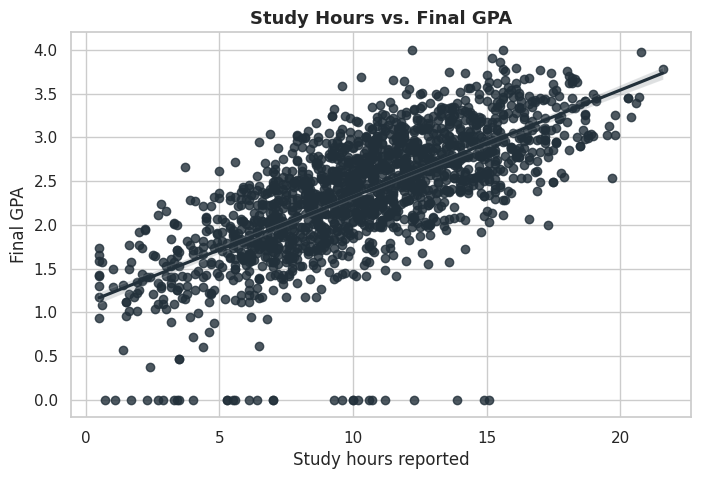

In [18]:
# Copy the closest cell from the Guided notebook, then fill in the blanks.
#
#   fig, ax = plt.subplots()
#   sns.__________(data=________, x="__________", color=NAVY, ax=ax)   # which chart? which column(s)?
#   ax.set_title("__________")
#   ax.set_xlabel("__________")
#   ax.set_ylabel("__________")
#   plt.show()

# --- your code below ---

fig, ax = plt.subplots()
sns.regplot(data=students, x="study_hours_reported", y="final_gpa", color=NAVY, ax=ax)
ax.set_title("Study Hours vs. Final GPA")
ax.set_xlabel("Study hours reported")
ax.set_ylabel("Final GPA")
plt.show()

**STAR story — Part B** *(write in your own words)*

- **Scope —** This graph shows the relationship between the number of study hours studnets reported and their final gpa
- **Track —** I wanted to see if students who reported studying more tended to have higher GPA's
- **Articulate —** The graph shows how the GPAs are spread across difrrent amounts of study hours.
- **Respond —** One thing I noticed was that studying more does now always mean having a higher GPA.

# Before you submit — checklist
- [ ] The notebook **runs top to bottom** with no errors (Runtime → Restart and run all).
- [ ] All **6 charts** are present, each with a title, labeled axes, and units/legend where needed.
- [ ] Each chart has a **complete STAR story**, including any exceptions you spotted.
- [ ] Part B question is written in and answered.
- [ ] Pushed to **GitHub**, and the **GitHub link** is submitted in Canvas.

**Rubric (70 pts):** chart choice 10 · correct build 20 · labeling 10 · STAR reading 18 · Part B question 4 · submission & professionalism 8.